PyTorch uses:
```
Autograd
```
to compute gradients automatically.

### What is Autograd?
#### Definition
Autograd is PyTorch's automatic differentiation engine.

It automatically:
* Tracks Operations
* Builds Computation Graph
* Computes Gradients
* Performs Backpropagation

### Why Is It Needed?
Imagine GPT with:
```
7 Billion Parameters
```

Computing gradients manually would be impossible.

Autograd handles it automatically.

### Core Idea
Suppose:
```
y = x²

dy/dx = 2x
```

At:
```
x = 3
```

gradient:
```
6
```

Autograd computes this automatically.

### Step 1: Enable Gradient Tracking

In [1]:
import torch

x = torch.tensor(
    3.0,
    requires_grad=True
)

print(x)

tensor(3., requires_grad=True)


#### What is requires_grad?
It tells PyTorch:
```
Track Everything
That Happens To This Tensor
```

because gradients are needed later.

#### Step 2: Build a Computation

In [2]:
y = x ** 2

For:
```
x = 3
```

Output:
```
y = 9
```

### Step 3: Backward Pass

In [3]:
y.backward()

This triggers:
```
Backpropagation
```

### Step 4: Access Gradient

In [4]:
print(x.grad)

tensor(6.)


Because:
```
dy/dx = 2x
```
```
2 × 3 = 6
```

### Full Example

In [5]:
import torch

x = torch.tensor(
    3.0,
    requires_grad=True
)

y = x ** 2

y.backward()

print(x.grad)

tensor(6.)


### Computational Graph
Autograd internally builds:
```
x
 ↓
Square
 ↓
y
```

During:
```python
y.backward()
```

it traverses the graph backwards and computes gradients.

### More Complex Example

In [6]:
import torch

x = torch.tensor(
    2.0,
    requires_grad=True
)

y = x**2 + 3*x + 1

y.backward()

print(x.grad)

tensor(7.)


#### Manual Math
Equation:
```
y = x² + 3x + 1
```

Derivative:
```
dy/dx = 2x + 3
```

At:
```
x = 2
```

Result:
```
7
```

Autograd Output:
```
tensor(7.)
```

Exactly correct.

### Computation Graph Visualization

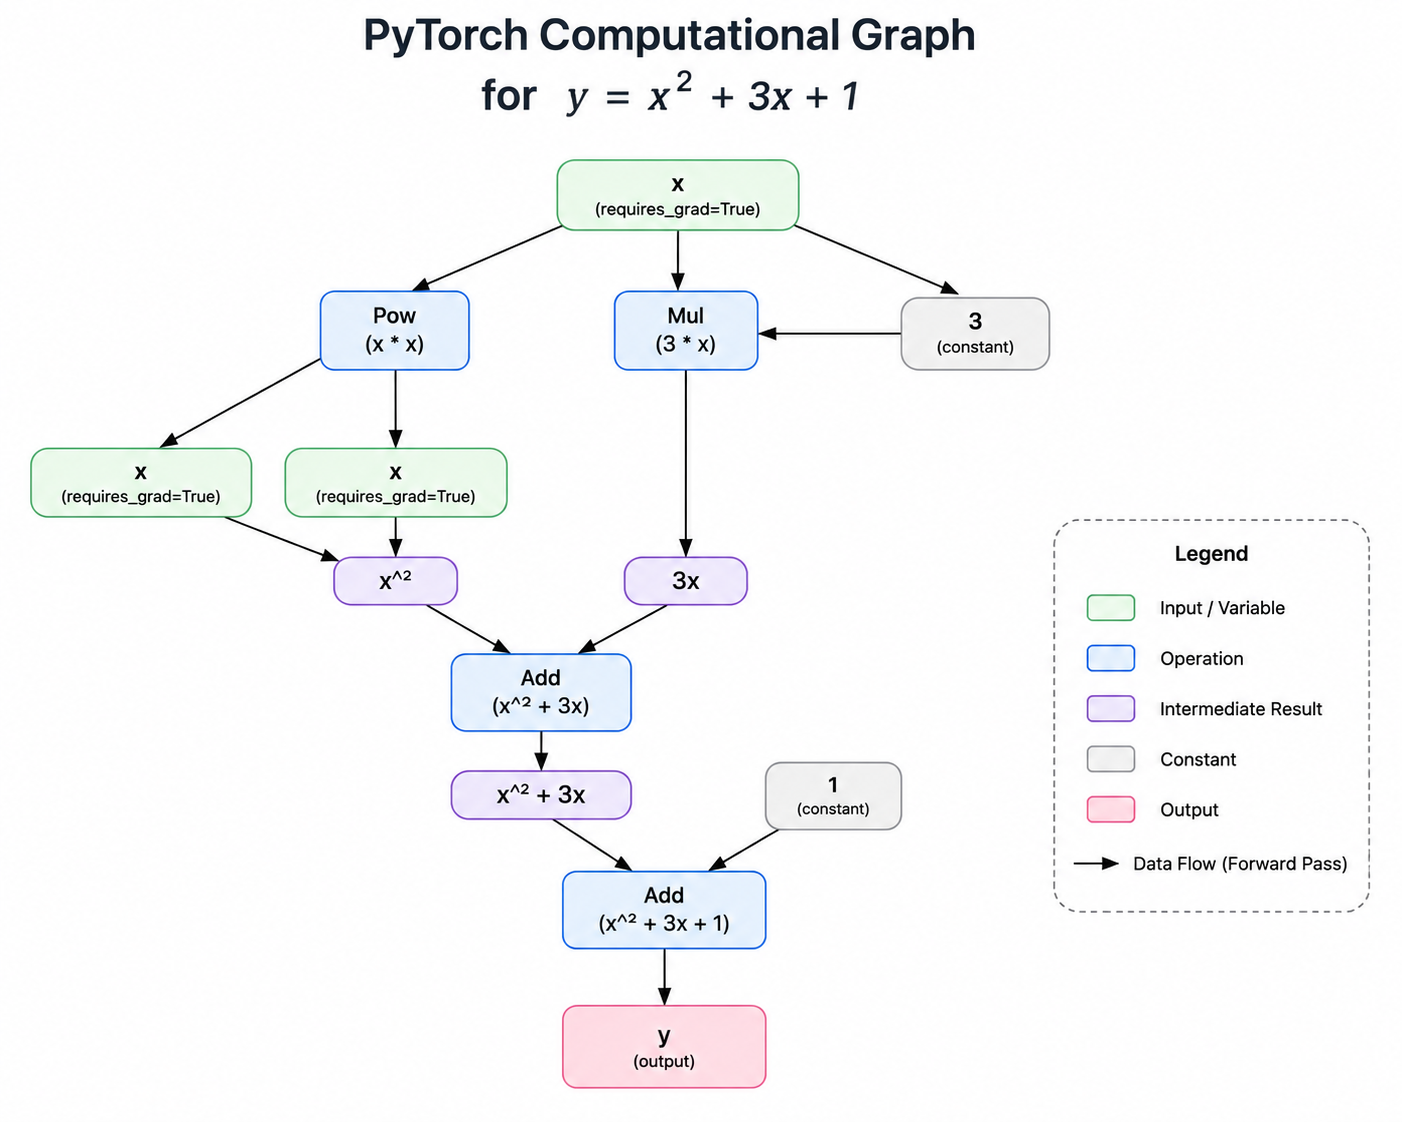

Autograd builds graphs like this automatically.

### Gradients in Neural Networks
Real neural networks have:
* Weights
* Biases
* Activations
* Loss

All tracked by Autograd.

Diagram:
```
Input
 ↓
Layer 1
 ↓
Layer 2
 ↓
Loss
```

Backward:
```
Loss
 ↑
Layer 2
 ↑
Layer 1
 ↑
Gradients
```

Autograd performs this automatically.

### Why backward() Works
Recall Phase 1:
```
Chain Rule
```

Autograd is essentially:
```
Automated Chain Rule Engine
```

for tensor operations.


### Gradient Accumulation
Important PyTorch behavior.

Suppose:


In [7]:
x = torch.tensor(
    3.0,
    requires_grad=True
)

y = x**2

y.backward()

print(x.grad)

tensor(6.)


Run again:
```python 
y.backward()
```

Gradient becomes:
```
12
```

because gradients accumulate.

### Why?
PyTorch assumes:
```
Multiple Backward Passes
May Be Needed
```

So it adds gradients instead of replacing them.

### Resetting Gradients
Before every training step:
```python 
optimizer.zero_grad()
```

Diagram:
```
Old Gradients
      ↓
Clear
      ↓
Compute New Gradients
```

Without this:
```
Gradients Keep Accumulating
```

and training becomes incorrect.

#### requires_grad=False
Not every tensor needs gradients.

Example:
```python 
x = torch.tensor([1,2,3])
```

Default:
```
requires_grad=False
```

Used for:
* Input Data
* Labels
* Constants

#### Trainable Parameters
Example:
```python 
layer = nn.Linear(
    10,
    5
)
```

Weights:
```
requires_grad=True
```

because they must learn.

#### Disabling Gradients
During inference:
```python 
with torch.no_grad():

    predictions = model(X)
```

Why?
```
No Training
No Backpropagation
```

Benefits:
* Faster
* Less Memory Usage

### Training Loop Connection
Everything comes together:
```
Input
 ↓
Forward Pass
 ↓
Loss
 ↓
loss.backward()
 ↓
Gradients
 ↓
optimizer.step()
 ↓
Updated Weights
```

### Most Important Three Lines
In almost every PyTorch training loop:
```python 
optimizer.zero_grad()

loss.backward()

optimizer.step()
```

#### Meaning
##### 1
```python
optimizer.zero_grad()
```

Clear old gradients.

##### 2
```python 
loss.backward()
```

Compute gradients using Autograd.

##### 3
```python
optimizer.step()
```

Update weights.